##Importing Libraries

In [3]:
import pandas as pd  #Pandas is used to analyze data
import numpy as np   #This library contains a large number of mathematical, algebraic, and transformation functions
import matplotlib.pyplot as plt  # Used for Visualization of data
import seaborn as sns   #Seaborn is a Python data visualization library based on matplotlib
#matplotlib inline sets the backend of matplotlib to the 'inline' backend
%matplotlib inline
sns.set_style('whitegrid')   # Set the aesthetic style of the plots
plt.style.use('fivethirtyeight')  #"fivethirtyeight" styling which tries to replicate the styles

##Loading dataset

In [4]:
# Loading the Dataset using Pandas Library using pd.read_csv(filename with extenstion)

df = pd.read_csv('/content/driver-data.csv')

In [5]:
# Printing the Total Row and Column usinf Shape

df.shape

(4000, 3)

In [6]:
# Printing First Five Rows of dataset using head()

df.head()

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25


In [7]:
# info(): This method prints information about a DataFrame including the index dtype and column dtypes, non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4000 non-null   int64  
 1   mean_dist_day         4000 non-null   float64
 2   mean_over_speed_perc  4000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 93.9 KB


In [9]:
# Checking for Null Values
df.isna().sum()

,0
id,0
mean_dist_day,0
mean_over_speed_perc,0


In [10]:
# remove null values
df.dropna(inplace=True)

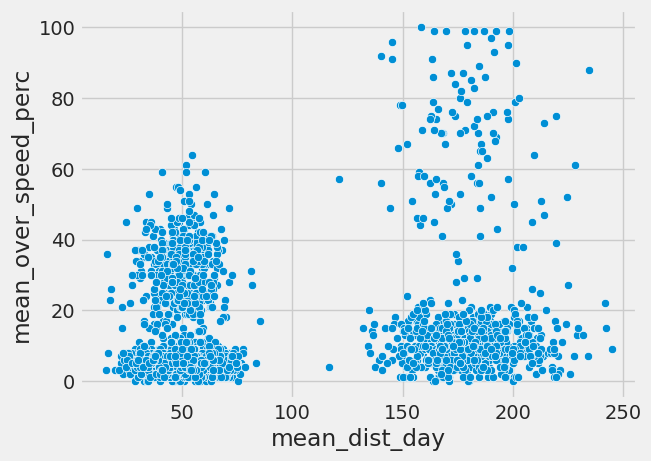

In [16]:
sns.scatterplot(x='mean_dist_day', y='mean_over_speed_perc', data=df)
plt.show()

##Model Creating and Fitting

In [18]:
#Import KMeans from SciKit Learn

from sklearn.cluster import KMeans

In [20]:
#Create an instance of a K Means model with 2 clusters(Goverment and Private)

kmeans = KMeans(n_clusters=2)
df_analyze = df.drop('id',axis=1)

In [21]:
#Fit the model to all the data except for the id label.
kmeans.fit(df_analyze)

KMeans(n_clusters=2)

In [22]:
# Q1. What are the cluster center vectors?

kmeans.cluster_centers_

array([[ 50.04763437,   8.82875   ],
       [180.017075  ,  18.29      ]])

In [23]:
# Check the lables of data point
# Check the size of labels -- should match dataset count
print(f"Labels: {kmeans.labels_}")
print(f"Size of labels: {len(kmeans.labels_)}")

Labels: [0 0 0 ... 1 1 1]
Size of labels: 4000


In [25]:
# Q2. How many drivers are there in 1st and 2nd Cluster?
print(f"drivers : {type(kmeans.labels_)}")
print (f"Cluster 1: {kmeans.labels_.tolist().count(0)}")
print (f"Cluster 2: {kmeans.labels_.tolist().count(1)}")
unique, counts = np.unique(kmeans.labels_, return_counts=True)
print(f"unique, counts :{dict(zip(unique, counts))}")

drivers : <class 'numpy.ndarray'>
Cluster 1: 3200
Cluster 2: 800
{np.int32(0): np.int64(3200), np.int32(1): np.int64(800)}
unique, counts :{np.int32(0): np.int64(3200), np.int32(1): np.int64(800)}


## Plot the Cluster Data

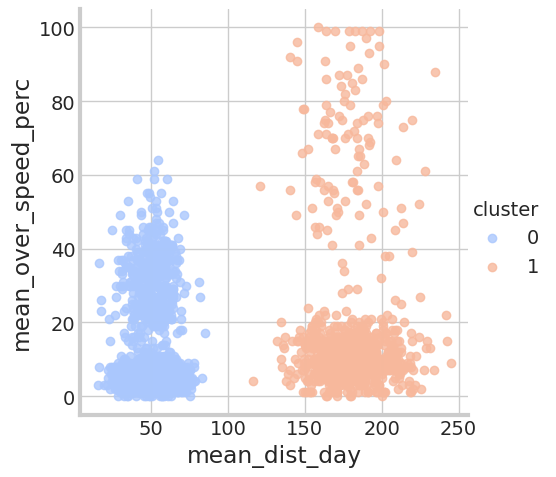

In [29]:
# plot the data
df_analyze['cluster'] = kmeans.labels_
sns.set_style('whitegrid')
sns.lmplot(x='mean_dist_day', y='mean_over_speed_perc', data=df_analyze, hue='cluster',
           palette='coolwarm',aspect=1,fit_reg=False)

## Now cluster the data in 4 groups and answer the same questions as for 2 groups

In [30]:
kmeans_4 = KMeans(n_clusters=4)
kmeans_4.fit(df.drop('id',axis=1))
kmeans_4.fit(df.drop('id',axis=1))
print(kmeans_4.cluster_centers_)
unique, counts = np.unique(kmeans_4.labels_, return_counts=True)

kmeans_4.cluster_centers_
print(dict(zip(unique, counts)))

[[ 58.03221662   7.34193955]
 [180.43486331  10.5294964 ]
 [ 42.22805332  10.28952263]
 [177.83509615  70.28846154]]
{np.int32(0): np.int64(1609), np.int32(1): np.int64(695), np.int32(2): np.int64(1592), np.int32(3): np.int64(104)}


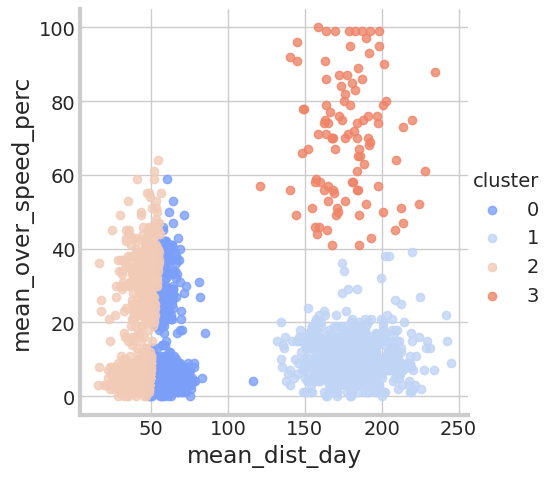

In [33]:
# plot the data
df_analyze['cluster'] = kmeans_4.labels_
sns.set_style('whitegrid')
sns.lmplot(x='mean_dist_day', y='mean_over_speed_perc', data=df_analyze, hue='cluster',
           palette='coolwarm',aspect=1,fit_reg=False)